# 04 — Task 3: Model exploration (race to the top)

Try classical ML models to maximize Macro F1. **No deep learning, no LLMs**. Document every model + key hyperparameters in code comments. Aim to explore >4 models.

## 0. Setup

Imports, src helpers, paths.

In [1]:
# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from src import paths, data, evaluation
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load features + the locked split

In [2]:
X, y, ids = data.load_train_features()
dev_idx = np.load(paths.DATA_PROCESSED / 'dev_idx.npy')

## 2. CV configuration and scoring

In [3]:
cv = evaluation.make_cv()

## 3. Baseline sweep

Each model gets one Macro F1 baseline under the same locked 5-fold Stratified CV, before
any tuning. Relevant context from 01_eda: the class balance is skewed (62.5% machine /
37.5% human), the matrix is 98.6% sparse across 5000 features, no single feature is
strongly dominant, and PCA compresses the space poorly. Every model below documents its
imbalance-handling and key hyperparameters; results are interpreted after the sweep runs.

In [4]:
n_pos = int((y[dev_idx] == 1).sum())  # machine, majority class
n_neg = int((y[dev_idx] == 0).sum())  # human, minority class

models = {
    # Linear SVM - suggested addition. Margin maximization on sparse high-dim TF-IDF is
    # a common strong choice for bag-of-words text classification.
    "LinearSVC": LinearSVC(class_weight="balanced", max_iter=5000, random_state=42),

    # LogReg Ridge (L2) - the default, well-behaved choice for p ~ n_features/4.
    "LogReg_Ridge": LogisticRegression(
        penalty="l2", solver="lbfgs", max_iter=2000,
        class_weight="balanced", random_state=42,
    ),
    # LogReg Lasso (L1) - the class signal here is diffuse across thousands of weak
    # features (no dominant feature in the EDA), so this variant tests whether
    # aggressive zeroing helps (removes noise) or hurts (discards real weak signal).
    "LogReg_Lasso": LogisticRegression(
        penalty="l1", solver="liblinear", max_iter=2000,
        class_weight="balanced", random_state=42,
    ),
    # LogReg ElasticNet - compromise between the two: some sparsity, but groups
    # correlated features instead of arbitrarily picking one and zeroing the rest.
    "LogReg_ElasticNet": LogisticRegression(
        penalty="elasticnet", solver="saga", l1_ratio=0.5, max_iter=2000,
        class_weight="balanced", random_state=42,
    ),

    # Multinomial Naive Bayes - classic bag-of-words baseline. TF-IDF values are
    # confirmed non-negative in the EDA, so they're valid MultinomialNB input despite
    # not being raw counts.
    "MultinomialNB": MultinomialNB(),
    # Complement NB - suggested addition. Same input validity as MultinomialNB, but
    # explicitly designed to correct for class imbalance, which plain MultinomialNB
    # has no lever for.
    "ComplementNB": ComplementNB(),

    # Random Forest - class_weight handles the imbalance; n_jobs=-1 to parallelize.
    "RandomForest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=42,
    ),
    # XGBoost - no class_weight lever; scale_pos_weight is XGBoost's imbalance handle,
    # computed from the actual dev-split class counts (label 1 is the majority here,
    # so this comes out below 1, downweighting it relative to the minority label 0).
    "XGBoost": XGBClassifier(
        n_estimators=300, tree_method="hist", eval_metric="logloss",
        scale_pos_weight=n_neg / n_pos, random_state=42,
    ),
    # LightGBM - leaf-wise growth tends to be more sample-efficient than XGBoost's
    # level-wise growth or RF's per-split subsampling on sparse high-dim data.
    "LightGBM": LGBMClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, verbose=-1,
    ),
    # HistGradientBoosting - bonus comparison point, sklearn's own fast native GBM.
    "HistGB": HistGradientBoostingClassifier(class_weight="balanced", random_state=42),
    # AdaBoost - a depth-1 stump splits on one feature at a time, tested here against
    # the diffuse multi-feature signal from the EDA. No class_weight on the stump:
    # AdaBoost already reweights samples every round, and stacking class_weight
    # ='balanced' on top double-corrects for the imbalance, which can push the
    # weighted stump error above 0.5 and abort the fit ("BaseClassifier ... is worse
    # than random") - confirmed this in practice.
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=200, random_state=42,
    ),

    # KNN - full 5000-dim, no PCA (Task 3 doesn't require it). Cosine over Euclidean
    # since that's the standard metric for TF-IDF vectors. n_neighbors=5 is a typical
    # independent default, deliberately different from Task 2's fixed n_neighbors=2 -
    # this is not a repeat of that experiment, just a separate comparison point.
    "KNN": KNeighborsClassifier(n_neighbors=5, metric="cosine", n_jobs=-1),
}

results = {}
for name, est in models.items():
    print(f"Running {name}...")
    results[name] = evaluation.evaluate_model_cv(est, X[dev_idx], y[dev_idx], cv=cv)
    print(f"  {name}: mean={results[name]['mean']:.4f}  std={results[name]['std']:.4f}")

Running LinearSVC...


  LinearSVC: mean=0.7228  std=0.0034
Running LogReg_Ridge...


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM: mean=0.7391  std=0.0055
Running HistGB...


  HistGB: mean=0.7262  std=0.0091
Running AdaBoost...


  AdaBoost: mean=0.5978  std=0.0102
Running KNN...


  KNN: mean=0.6542  std=0.0131


## 4. Collect results

Persist as the experiment ledger.

In [5]:
results_df = pd.DataFrame(results).T.sort_values("mean", ascending=False)
results_df.insert(0, "rank", np.arange(1, len(results_df) + 1))
print(results_df.to_string())

paths.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
results_df.to_csv(paths.DATA_PROCESSED / "baseline_results.csv")

                   rank                                                                                                scores      mean       std
LightGBM              1               [0.7307925853869099, 0.748, 0.7379811561016791, 0.7407882575429636, 0.7381191234780764]  0.739136  0.005537
XGBoost               2  [0.7296823974204448, 0.7355565062239797, 0.7301579759103192, 0.7248321307328838, 0.7241963427009614]  0.728885  0.004127
HistGB                3    [0.71028445717339, 0.7372961635959587, 0.7291710119466742, 0.7310516347324565, 0.7233072916666667]  0.726222  0.009134
LogReg_Ridge          4   [0.7208668585707014, 0.7206050909350208, 0.7235854996477319, 0.7290053787130608, 0.729098718565649]  0.724632  0.003757
LinearSVC             5     [0.7213021477396008, 0.7260890800319084, 0.717409454926314, 0.726684259662637, 0.722418063496868]  0.722781  0.003387
LogReg_ElasticNet     6  [0.7112914758828326, 0.7217260749139293, 0.7216263929326197, 0.7285408798644407, 0.7148283300332037

## 5. Visualize the comparison

Loads `baseline_results.csv` from disk rather than reusing the in-memory `results_df`, so
the plot can be regenerated any time without rerunning the sweep. Mean Macro F1 with the
fold-to-fold std as error bars, sorted best to worst, against a red reference line for
plain logistic regression (Ridge, balanced) as a fast, well-understood anchor point.

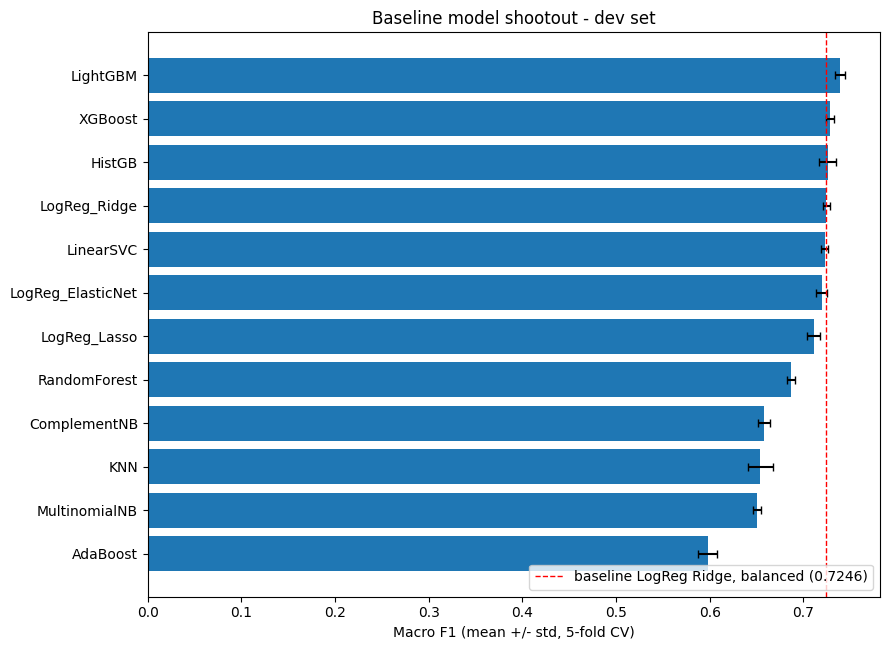

In [6]:
results_df = pd.read_csv(paths.DATA_PROCESSED / "baseline_results.csv", index_col=0)

BASELINE_F1_MEAN = results_df.loc["LogReg_Ridge", "mean"]
labels = results_df.index

fig, ax = plt.subplots(figsize=(9, max(3, 0.55 * len(results_df))))
ax.barh(labels, results_df["mean"], xerr=results_df["std"], capsize=3)
ax.invert_yaxis()
ax.axvline(BASELINE_F1_MEAN, color="red", linestyle="--", linewidth=1,
           label=f"baseline LogReg Ridge, balanced ({BASELINE_F1_MEAN:.4f})")
ax.set_xlabel("Macro F1 (mean +/- std, 5-fold CV)")
ax.set_title("Baseline model shootout - dev set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES / "baseline_models_cv_f1.png", dpi=120)
plt.show()

## Discussion / carry-forward -> `05_tuning.ipynb`

**Results (Macro F1, 5-fold Stratified CV on dev_idx):**

| rank | model | mean F1 | std |
|---|---|---|---|
| 1 | LightGBM | 0.7391 | 0.0055 |
| 2 | XGBoost | 0.7289 | 0.0041 |
| 3 | HistGB | 0.7262 | 0.0091 |
| 4 | LogReg_Ridge | 0.7246 | 0.0038 |
| 5 | LinearSVC | 0.7228 | 0.0034 |
| 6 | LogReg_ElasticNet | 0.7196 | 0.0060 |
| 7 | LogReg_Lasso | 0.7112 | 0.0070 |
| 8 | RandomForest | 0.6871 | 0.0043 |
| 9 | ComplementNB | 0.6580 | 0.0067 |
| 10 | KNN | 0.6542 | 0.0131 |
| 11 | MultinomialNB | 0.6505 | 0.0046 |
| 12 | AdaBoost | 0.5978 | 0.0102 |

**Gradient-boosted trees swept the top 3 spots**, with linear models forming a solid
middle tier and both Naive Bayes variants near the bottom, below even Random Forest. With
300 estimators and unrestricted depth, gradient boosting doesn't need one strong feature
per split the way a single shallow tree does - across enough rounds it chains together
many weak, correlated features, which suits the diffuse TF-IDF signal seen in the EDA
(no single dominant feature). Naive Bayes underperforming fits the same picture from the
other direction: its independence assumption breaks down when thousands of TF-IDF
features are correlated with each other (shared vocabulary co-occurring within a class),
something boosting and linear models both handle better.

**Bug found and fixed:** AdaBoost's first run failed on 2 of 5 folds
(`BaseClassifier ... is worse than random, ensemble can not be fit`) because the stump had
`class_weight="balanced"` stacked on top of AdaBoost's own per-round sample reweighting,
double-correcting for the imbalance until the weighted error exceeded 0.5. Removed
`class_weight` from the stump; AdaBoost still finishes last, but now legitimately rather
than crashing.

**Carrying forward to `05_tuning.ipynb`:** tune LightGBM and XGBoost first, the two clear
leaders. LogReg_Ridge is worth a light tuning pass too as a fast, well-understood
alternative in case boosting overfits more on the held-out/leaderboard split than CV
suggests (the brief's documented train-to-test shift is exactly the situation where a
strong CV winner is not automatically the strongest real submission).